# R Mortality Improvement Modelling — Dummy USA Mortality Data

This notebook demonstrates a complete workflow for mortality improvement modelling for r m analysis using a **dummy annual mortality-rate dataframe**.

The dummy data represents:

- Rows: calendar years 1950–2020
- Columns: ages 50–100
- Values: annual probability of death between exact age `x` and `x+1`, usually denoted `q_x`

The notebook covers:

1. Creating dummy mortality data
2. Segmenting ages into cohorts: 50–74, 75–89, 90–100
3. Calculating annual mortality improvement factors
4. Smoothing improvement factors by cohort
5. Applying improvement factors to base mortality rates
6. Comparing with the age-setback method
7. Running Monte Carlo mortality projections
8. Interpreting which method is better for projection vs prediction

The data is synthetic and designed for demonstration only. Replace it with HMD data later when available.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

START_YEAR = 1950
END_YEAR = 2020
YEARS = np.arange(START_YEAR, END_YEAR + 1)

AGES = np.arange(50, 101)  # 50 to 100 inclusive

COHORTS = {
    "50-74": list(range(50, 75)),
    "75-89": list(range(75, 90)),
    "90-100": list(range(90, 101)),
}

BASE_YEAR = 2020
PROJECTION_YEARS = np.arange(2021, 2051)


## 1. Create dummy annual mortality-rate dataframe

In [2]:
# Create dummy annual mortality rates q_x,t
# Values are probability of death between age x and x+1.
#
# The dummy data has realistic shape:
# - mortality increases with age
# - mortality generally improves over calendar time
# - improvement is stronger at younger old ages and weaker at very high ages
# - random annual noise is included

def make_dummy_mortality_rates(years, ages, seed=42):
    rng = np.random.default_rng(seed)

    rows = []
    for year in years:
        years_since_1950 = year - years[0]

        row = {"Year": year}

        for age in ages:
            # Gompertz-like base mortality at 1950
            # age 50 around 0.7%, age 80 around 6%, age 100 much higher
            base_q_1950 = 0.007 * np.exp(0.085 * (age - 50))

            # Mortality improvement differs by age cohort
            if age <= 74:
                annual_improvement = 0.0135
            elif age <= 89:
                annual_improvement = 0.0090
            else:
                annual_improvement = 0.0040

            # Long-term deterministic improvement from 1950 to current year
            trend_factor = (1 - annual_improvement) ** years_since_1950

            # Period shock examples, purely illustrative
            # temporary higher mortality around 1968 and 2020
            shock = 1.0
            if year == 1968:
                shock *= 1.04
            if year == 2020:
                shock *= 1.08

            # Random noise: more noise at older ages
            noise_sd = 0.015 if age <= 74 else 0.025 if age <= 89 else 0.045
            noise = rng.normal(0, noise_sd)

            q = base_q_1950 * trend_factor * shock * np.exp(noise)

            # Keep q inside plausible probability bounds
            q = np.clip(q, 0.0005, 0.65)

            row[age] = q

        rows.append(row)

    qx_wide = pd.DataFrame(rows).set_index("Year")
    qx_wide.columns.name = "Age"
    return qx_wide


qx = make_dummy_mortality_rates(YEARS, AGES, seed=RANDOM_SEED)

print("Dummy mortality-rate dataframe: q_x,t")
print("Rows = years, columns = ages, values = annual probability of death")
display(qx.head())
display(qx.tail())


Dummy mortality-rate dataframe: q_x,t
Rows = years, columns = ages, values = annual probability of death


Age,50,51,52,53,54,55,56,57,58,59,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
1950,0.007032,0.007503,0.008391,0.009162,0.009551,0.010500,0.011679,0.012631,0.013814,0.014852,...,0.234007,0.241281,0.273515,0.296237,0.324002,0.363262,0.384127,0.426862,0.452122,0.497164
1951,0.006971,0.007356,0.008146,0.008849,0.009609,0.010519,0.011760,0.012358,0.013830,0.014470,...,0.223152,0.246735,0.249878,0.275003,0.301081,0.332628,0.385635,0.395898,0.441371,0.518203
1952,0.006776,0.007499,0.007962,0.008764,0.009435,0.010367,0.011488,0.012035,0.013535,0.014692,...,0.229279,0.237772,0.263539,0.284391,0.316258,0.363531,0.379920,0.407791,0.426789,0.451481
1953,0.006671,0.007311,0.008180,0.008689,0.009582,0.010203,0.010994,0.012009,0.013122,0.014910,...,0.214663,0.235951,0.275293,0.286039,0.316922,0.342589,0.381487,0.435817,0.447181,0.499128
1954,0.006429,0.007212,0.007759,0.008400,0.009192,0.010090,0.011193,0.011783,0.013092,0.014144,...,0.212076,0.232880,0.289322,0.330500,0.299513,0.338088,0.380029,0.440394,0.424312,0.477632


Age,50,51,52,53,54,55,56,57,58,59,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
2016,0.002856,0.003094,0.003399,0.003690,0.003995,0.004267,0.004649,0.005130,0.005633,0.006078,...,0.188969,0.195114,0.207383,0.204915,0.224836,0.269671,0.287226,0.302360,0.347002,0.378631
2017,0.002856,0.003072,0.003400,0.003634,0.003949,0.004376,0.004621,0.005325,0.005589,0.006086,...,0.172798,0.196787,0.207879,0.211411,0.231180,0.250942,0.297225,0.347320,0.366385,0.344486
2018,0.002838,0.003067,0.003217,0.003568,0.003967,0.004284,0.004536,0.005083,0.005310,0.005950,...,0.165955,0.193707,0.193571,0.218156,0.256409,0.270269,0.285620,0.321647,0.342291,0.373878
2019,0.002767,0.002951,0.003250,0.003520,0.003759,0.004134,0.004672,0.004997,0.005303,0.005754,...,0.178869,0.189513,0.193995,0.221786,0.258919,0.285660,0.297864,0.297612,0.349476,0.386699
2020,0.002952,0.003216,0.003479,0.003763,0.004065,0.004340,0.004887,0.005308,0.005811,0.006150,...,0.179983,0.197598,0.216254,0.221171,0.272078,0.300645,0.300591,0.343085,0.363348,0.406296


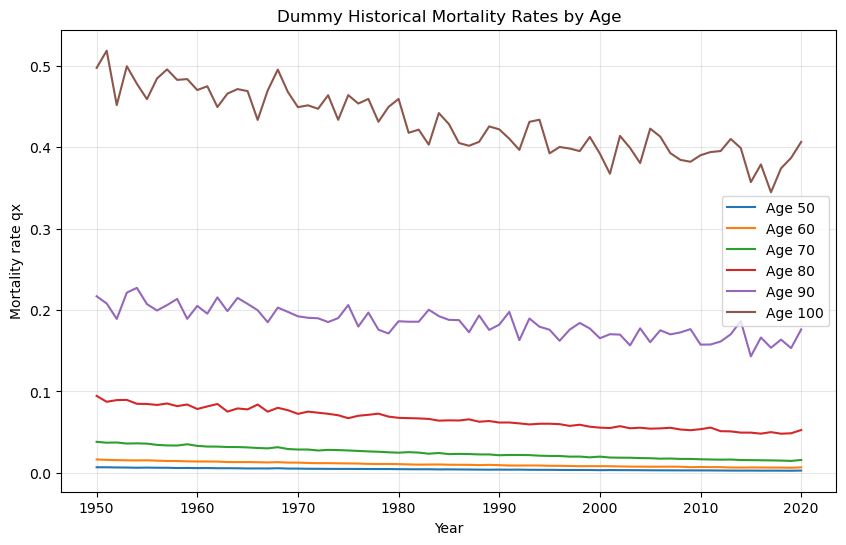

In [3]:
# Plot selected historical mortality rates

selected_ages = [50, 60, 70, 80, 90, 100]

plt.figure(figsize=(10, 6))
for age in selected_ages:
    plt.plot(qx.index, qx[age], label=f"Age {age}")

plt.title("Dummy Historical Mortality Rates by Age")
plt.xlabel("Year")
plt.ylabel("Mortality rate qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2. Calculate mortality improvement factors

In [4]:
# Calculate annual mortality improvement factors
#
# Improvement is defined as:
# MI_x,t = 1 - q_x,t / q_x,t-1
#
# Positive MI means mortality improved.
# Negative MI means mortality worsened.

mi = 1 - qx / qx.shift(1)
mi = mi.dropna()

print("Annual mortality improvement factors")
display(mi.head())

# Alternative log improvement:
# log_mi_x,t = -log(q_x,t / q_x,t-1)
log_mi = -np.log(qx / qx.shift(1))
log_mi = log_mi.dropna()

display(log_mi.head())


Annual mortality improvement factors


Age,50,51,52,53,54,55,56,57,58,59,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
1951,0.008656,0.019654,0.029209,0.034159,-0.006109,-0.001815,-0.006939,0.021599,-0.001185,0.025703,...,0.046388,-0.022604,0.086421,0.071680,0.070744,0.084329,-0.003928,0.072540,0.023779,-0.042318
1952,0.028006,-0.019516,0.022543,0.009572,0.018093,0.014445,0.023140,0.026166,0.021368,-0.015333,...,-0.027458,0.036327,-0.054673,-0.034137,-0.050407,-0.092903,0.014820,-0.030042,0.033037,0.128757
1953,0.015422,0.025140,-0.027297,0.008520,-0.015519,0.015869,0.043018,0.002157,0.030512,-0.014879,...,0.063749,0.007659,-0.044599,-0.005796,-0.002099,0.057606,-0.004124,-0.068726,-0.047779,-0.105536
1954,0.036372,0.013425,0.051392,0.033262,0.040656,0.011053,-0.018082,0.018832,0.002252,0.051413,...,0.012052,0.013015,-0.050959,-0.155435,0.054932,0.013137,0.003822,-0.010501,0.051139,0.043068
1955,-0.029240,0.006320,0.006564,-0.002687,0.020823,0.012079,0.030841,-0.009835,0.022133,-0.000744,...,-0.069558,-0.029024,0.152718,0.113058,-0.134785,0.054896,-0.019685,0.092066,-0.038358,0.039548


Age,50,51,52,53,54,55,56,57,58,59,...,91,92,93,94,95,96,97,98,99,100
Year,,,,,,,,,,,,,,,,,,,,,
1951,0.008693,0.019850,0.029644,0.034756,-0.006090,-0.001814,-0.006915,0.021836,-0.001184,0.026039,...,0.047498,-0.022353,0.090385,0.074379,0.073370,0.088098,-0.003920,0.075306,0.024066,-0.041447
1952,0.028405,-0.019328,0.022801,0.009618,0.018259,0.014550,0.023411,0.026514,0.021600,-0.015217,...,-0.027087,0.037003,-0.053231,-0.033568,-0.049178,-0.088837,0.014931,-0.029600,0.033595,0.137834
1953,0.015543,0.025461,-0.026931,0.008556,-0.015399,0.015996,0.043971,0.002159,0.030987,-0.014769,...,0.065872,0.007688,-0.043633,-0.005779,-0.002097,0.059332,-0.004116,-0.066467,-0.046673,-0.100330
1954,0.037050,0.013516,0.052759,0.033828,0.041505,0.011114,-0.017921,0.019011,0.002254,0.052782,...,0.012125,0.013101,-0.049703,-0.144477,0.056498,0.013224,0.003829,-0.010447,0.052493,0.044023
1955,-0.028821,0.006340,0.006586,-0.002683,0.021043,0.012153,0.031326,-0.009786,0.022381,-0.000744,...,-0.067246,-0.028611,0.165722,0.119976,-0.126443,0.056461,-0.019494,0.096583,-0.037641,0.040351


## 3. Cohort-level analysis

Cohort average mortality rates


,50-74,75-89,90-100
Year,,,
1950,0.023271,0.113876,0.337224
1951,0.022929,0.112650,0.325234
1952,0.022734,0.112014,0.322708
1953,0.022338,0.111367,0.332400
1954,0.022107,0.107411,0.331992


Cohort average annual mortality improvement factors


,50-74,75-89,90-100
Year,,,
1951,0.014559,0.013475,0.038914
1952,0.011528,0.009542,0.001311
1953,0.013391,-0.001285,-0.029133
1954,0.014286,0.033024,-0.004738
1955,0.010193,-0.003531,0.022606


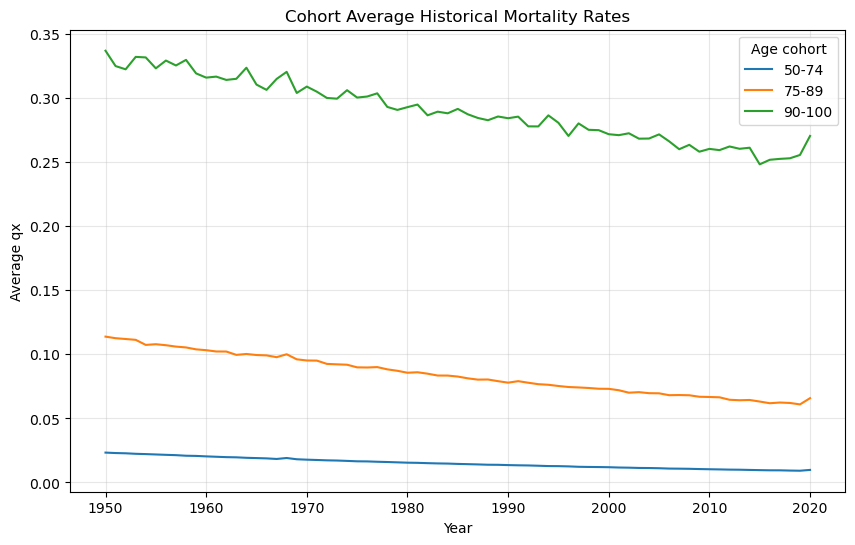

In [5]:
# Cohort-level mortality rates and improvement factors

def cohort_average(df, cohorts):
    out = pd.DataFrame(index=df.index)
    for name, ages in cohorts.items():
        existing_ages = [age for age in ages if age in df.columns]
        out[name] = df[existing_ages].mean(axis=1)
    return out

qx_cohort = cohort_average(qx, COHORTS)
mi_cohort = cohort_average(mi, COHORTS)

print("Cohort average mortality rates")
display(qx_cohort.head())

print("Cohort average annual mortality improvement factors")
display(mi_cohort.head())

plt.figure(figsize=(10, 6))
for col in qx_cohort.columns:
    plt.plot(qx_cohort.index, qx_cohort[col], label=col)

plt.title("Cohort Average Historical Mortality Rates")
plt.xlabel("Year")
plt.ylabel("Average qx")
plt.legend(title="Age cohort")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Smooth improvement assumptions

Recent smoothed improvement by cohort


,Recent annual MI
50-74,0.012905
75-89,0.007815
90-100,0.001888


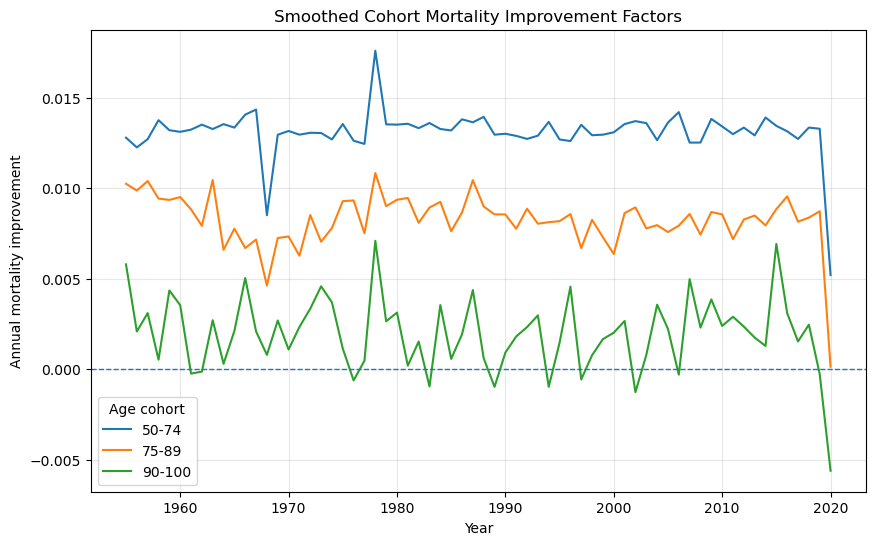

In [6]:
# Smooth improvement factors
#
# Raw annual improvements are noisy, especially at older ages.
# We use a rolling average and then estimate recent improvement from 2000-2020.

SMOOTHING_WINDOW = 10
RECENT_START_YEAR = 2000

mi_smooth = mi.rolling(SMOOTHING_WINDOW, min_periods=5).mean()
mi_cohort_smooth = mi_cohort.rolling(SMOOTHING_WINDOW, min_periods=5).mean()

recent_mi_by_age = mi_smooth.loc[RECENT_START_YEAR:END_YEAR].mean()
recent_mi_by_cohort = mi_cohort_smooth.loc[RECENT_START_YEAR:END_YEAR].mean()

# Cap improvements to avoid unrealistic dummy-data outliers
recent_mi_by_age = recent_mi_by_age.clip(lower=-0.01, upper=0.03)
recent_mi_by_cohort = recent_mi_by_cohort.clip(lower=-0.01, upper=0.03)

print("Recent smoothed improvement by cohort")
display(recent_mi_by_cohort.to_frame("Recent annual MI"))

plt.figure(figsize=(10, 6))
for col in mi_cohort_smooth.columns:
    plt.plot(mi_cohort_smooth.index, mi_cohort_smooth[col], label=col)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Smoothed Cohort Mortality Improvement Factors")
plt.xlabel("Year")
plt.ylabel("Annual mortality improvement")
plt.legend(title="Age cohort")
plt.grid(True, alpha=0.3)
plt.show()


## 5. Apply improvement factors to base mortality rates

Projected mortality rates


,50,51,52,53,54,55,56,57,58,59,...,91,92,93,94,95,96,97,98,99,100
2021,0.002913,0.003175,0.003434,0.003715,0.004012,0.004282,0.004824,0.005242,0.005736,0.006071,...,0.179610,0.197261,0.215596,0.220572,0.271872,0.300300,0.299989,0.342773,0.363278,0.406009
2022,0.002874,0.003135,0.003390,0.003668,0.003961,0.004225,0.004762,0.005178,0.005661,0.005993,...,0.179238,0.196925,0.214940,0.219975,0.271667,0.299956,0.299389,0.342462,0.363209,0.405722
2023,0.002837,0.003094,0.003345,0.003621,0.003910,0.004168,0.004702,0.005114,0.005588,0.005916,...,0.178867,0.196590,0.214285,0.219379,0.271461,0.299611,0.298790,0.342151,0.363139,0.405435
2024,0.002799,0.003055,0.003302,0.003574,0.003860,0.004112,0.004641,0.005050,0.005515,0.005841,...,0.178496,0.196255,0.213633,0.218785,0.271256,0.299267,0.298193,0.341840,0.363069,0.405148
2025,0.002763,0.003016,0.003259,0.003528,0.003810,0.004057,0.004582,0.004988,0.005443,0.005766,...,0.178126,0.195920,0.212983,0.218192,0.271051,0.298924,0.297596,0.341529,0.363000,0.404862


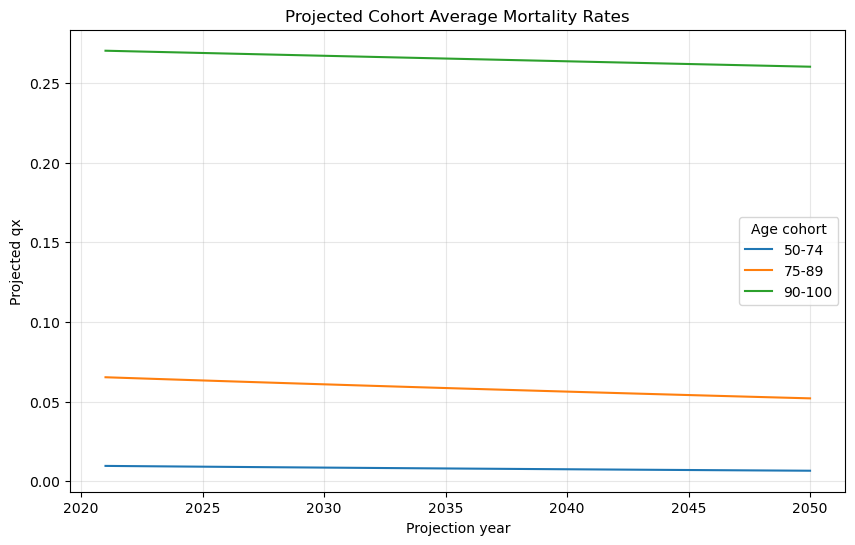

In [7]:
# Project mortality rates using improvement factors
#
# Formula:
# q_x,t = q_x,base * product over future years of (1 - MI_x,k)
#
# For this simple example, each age uses its recent smoothed improvement rate.
# We also taper improvements at very high ages to avoid aggressive longevity assumptions.

def taper_high_age_improvement(age, mi_value):
    if age < 90:
        return mi_value
    if age <= 100:
        # linearly taper from full at age 90 to 50% at age 100
        taper = 1.0 - 0.5 * ((age - 90) / 10)
        return mi_value * taper
    return mi_value * 0.5

base_qx = qx.loc[BASE_YEAR].copy()

age_mi_assumption = recent_mi_by_age.copy()
for age in age_mi_assumption.index:
    age_mi_assumption.loc[age] = taper_high_age_improvement(age, age_mi_assumption.loc[age])

# Keep assumptions in a reasonable range
age_mi_assumption = age_mi_assumption.clip(lower=0.0, upper=0.025)

projected_qx = pd.DataFrame(index=PROJECTION_YEARS, columns=AGES, dtype=float)

for age in AGES:
    q = base_qx.loc[age]
    mi_assump = age_mi_assumption.loc[age]

    for year in PROJECTION_YEARS:
        q = q * (1 - mi_assump)
        projected_qx.loc[year, age] = q

print("Projected mortality rates")
display(projected_qx.head())

projected_qx_cohort = cohort_average(projected_qx, COHORTS)

plt.figure(figsize=(10, 6))
for col in projected_qx_cohort.columns:
    plt.plot(projected_qx_cohort.index, projected_qx_cohort[col], label=col)

plt.title("Projected Cohort Average Mortality Rates")
plt.xlabel("Projection year")
plt.ylabel("Projected qx")
plt.legend(title="Age cohort")
plt.grid(True, alpha=0.3)
plt.show()


## 6. Age-setback method

,setback_0,setback_1,setback_3,setback_5
Age,,,,
50,0.002952,0.002952,0.002952,0.002952
60,0.006897,0.006150,0.005308,0.004340
70,0.015970,0.014559,0.012422,0.010772
80,0.052679,0.048907,0.039281,0.035778
90,0.176151,0.110393,0.096710,0.080252
100,0.406296,0.363348,0.300591,0.272078


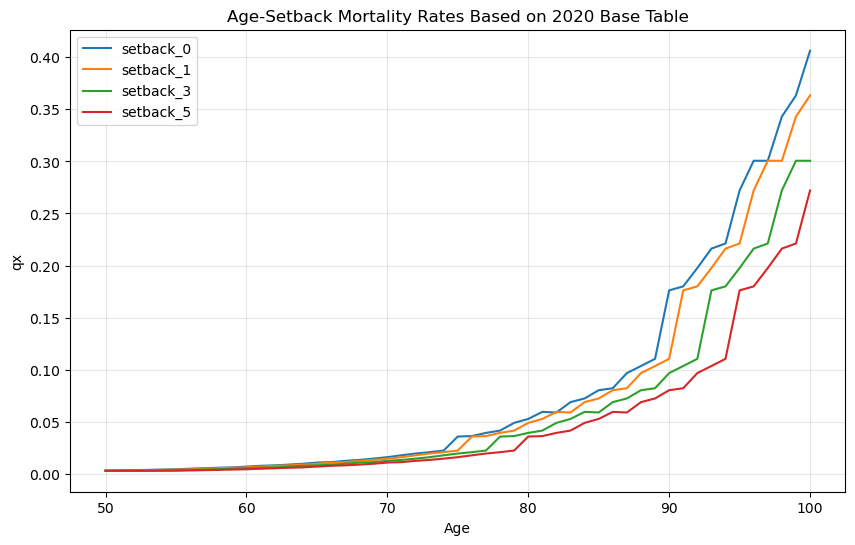

In [8]:
# Age-setback method
#
# Age setback says:
# projected q_x = base q_{x - s}
#
# Example:
# with a 3-year setback, projected q_80 = base q_77
#
# This is simple, but it does not naturally vary by calendar projection year.

def apply_age_setback(base_qx, setback_years):
    out = pd.Series(index=base_qx.index, dtype=float)

    min_age = int(base_qx.index.min())
    max_age = int(base_qx.index.max())

    for age in base_qx.index:
        setback_age = max(min_age, int(age - setback_years))
        out.loc[age] = base_qx.loc[setback_age]

    return out

setbacks = [0, 1, 3, 5]
age_setback_table = pd.DataFrame({f"setback_{s}": apply_age_setback(base_qx, s) for s in setbacks})

display(age_setback_table.loc[[50, 60, 70, 80, 90, 100]])

plt.figure(figsize=(10, 6))
for col in age_setback_table.columns:
    plt.plot(age_setback_table.index, age_setback_table[col], label=col)

plt.title("Age-Setback Mortality Rates Based on 2020 Base Table")
plt.xlabel("Age")
plt.ylabel("qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Compare methods

,base_2020,improvement_projection_2030,age_setback_3_years,projection_vs_base_pct,age_setback_vs_base_pct
50,0.002952,0.002586,0.002952,-0.123932,0.000000
60,0.006897,0.006075,0.005308,-0.119237,-0.230400
70,0.015970,0.013982,0.012422,-0.124453,-0.222139
80,0.052679,0.048788,0.039281,-0.073865,-0.254339
90,0.176151,0.174886,0.096710,-0.007182,-0.450979
100,0.406296,0.403433,0.300591,-0.007047,-0.260168


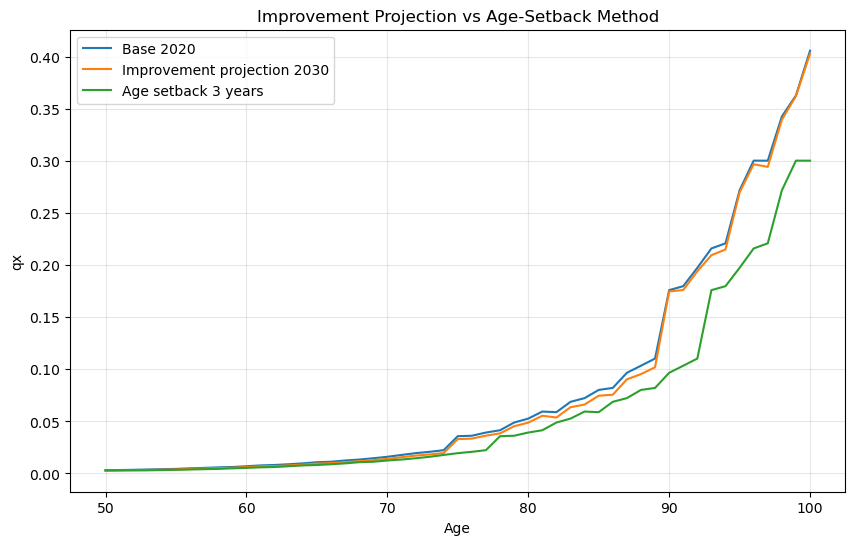

In [9]:
# Compare improvement-factor projection with age-setback approximation
#
# Here we compare projected mortality in 2030 from the improvement-factor method
# with a 3-year age setback from the 2020 base table.

comparison_year = 2030
setback_years = 3

comparison = pd.DataFrame({
    "base_2020": base_qx,
    f"improvement_projection_{comparison_year}": projected_qx.loc[comparison_year],
    f"age_setback_{setback_years}_years": apply_age_setback(base_qx, setback_years),
})

comparison["projection_vs_base_pct"] = comparison[f"improvement_projection_{comparison_year}"] / comparison["base_2020"] - 1
comparison["age_setback_vs_base_pct"] = comparison[f"age_setback_{setback_years}_years"] / comparison["base_2020"] - 1

display(comparison.loc[[50, 60, 70, 80, 90, 100]])

plt.figure(figsize=(10, 6))
plt.plot(comparison.index, comparison["base_2020"], label="Base 2020")
plt.plot(comparison.index, comparison[f"improvement_projection_{comparison_year}"], label=f"Improvement projection {comparison_year}")
plt.plot(comparison.index, comparison[f"age_setback_{setback_years}_years"], label=f"Age setback {setback_years} years")

plt.title("Improvement Projection vs Age-Setback Method")
plt.xlabel("Age")
plt.ylabel("qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Monte Carlo mortality-rate projections

,Mean qx 2050,5th percentile,50th percentile,95th percentile
Age,,,,
60,0.005445,0.004199,0.005382,0.006916
75,0.032644,0.025343,0.032262,0.041386
85,0.073086,0.056362,0.072137,0.093064
95,0.271716,0.210336,0.270263,0.341312
100,0.406227,0.316144,0.401632,0.508951


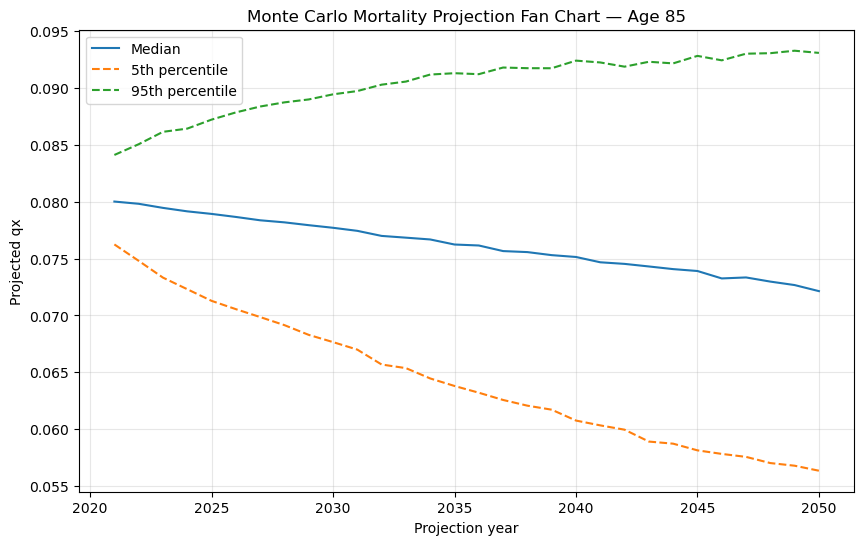

In [10]:
# Monte Carlo mortality projections
#
# Instead of using one fixed improvement assumption, simulate many future
# improvement paths.
#
# For each age:
# MI_x,t ~ Normal(mean historical MI, volatility historical MI)
#
# Then:
# q_x,t = q_x,t-1 * (1 - MI_x,t)
#
# This gives a distribution of projected mortality rates instead of one path.

N_SIMS = 2000
MC_END_YEAR = 2050
MC_YEARS = np.arange(BASE_YEAR + 1, MC_END_YEAR + 1)

# Historical volatility from recent smoothed/implied annual improvement
recent_mi_window = mi.loc[RECENT_START_YEAR:END_YEAR]

mi_mean = recent_mi_window.mean().clip(lower=0.0, upper=0.025)
mi_vol = recent_mi_window.std().fillna(0.005).clip(lower=0.002, upper=0.03)

# We simulate selected ages to keep the notebook fast and readable
mc_selected_ages = [60, 75, 85, 95, 100]

mc_results = {}

for age in mc_selected_ages:
    paths = np.zeros((N_SIMS, len(MC_YEARS)))
    q0 = base_qx.loc[age]
    mean = mi_mean.loc[age]
    vol = mi_vol.loc[age]

    for sim in range(N_SIMS):
        q = q0
        for j, year in enumerate(MC_YEARS):
            mi_draw = rng.normal(mean, vol)

            # Cap simulated improvement to avoid impossible or explosive values
            mi_draw = np.clip(mi_draw, -0.05, 0.05)

            q = q * (1 - mi_draw)
            q = np.clip(q, 0.0001, 0.90)

            paths[sim, j] = q

    mc_results[age] = pd.DataFrame(paths, columns=MC_YEARS)

# Summarise Monte Carlo distribution for year 2050
mc_summary_2050 = []

for age, paths in mc_results.items():
    vals = paths[MC_END_YEAR]
    mc_summary_2050.append({
        "Age": age,
        "Mean qx 2050": vals.mean(),
        "5th percentile": vals.quantile(0.05),
        "50th percentile": vals.quantile(0.50),
        "95th percentile": vals.quantile(0.95),
    })

mc_summary_2050 = pd.DataFrame(mc_summary_2050).set_index("Age")
display(mc_summary_2050)

# Plot Monte Carlo fan chart for one age
fan_age = 85
paths = mc_results[fan_age]

p05 = paths.quantile(0.05)
p50 = paths.quantile(0.50)
p95 = paths.quantile(0.95)

plt.figure(figsize=(10, 6))
plt.plot(MC_YEARS, p50, label="Median")
plt.plot(MC_YEARS, p05, linestyle="--", label="5th percentile")
plt.plot(MC_YEARS, p95, linestyle="--", label="95th percentile")

plt.title(f"Monte Carlo Mortality Projection Fan Chart — Age {fan_age}")
plt.xlabel("Projection year")
plt.ylabel("Projected qx")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9. Applicable interpretation

,Year,Attained age,qx,Survival probability
0,2021,76,0.035925,0.964075
1,2022,77,0.038665,0.926798
2,2023,78,0.040575,0.889194
3,2024,79,0.047462,0.846991
4,2025,80,0.050697,0.804051


,Year,Attained age,qx,Survival probability
20,2041,96,0.293481,0.071319
21,2042,97,0.287637,0.050805
22,2043,98,0.335986,0.033735
23,2044,99,0.361681,0.021534
24,2045,100,0.399176,0.012938


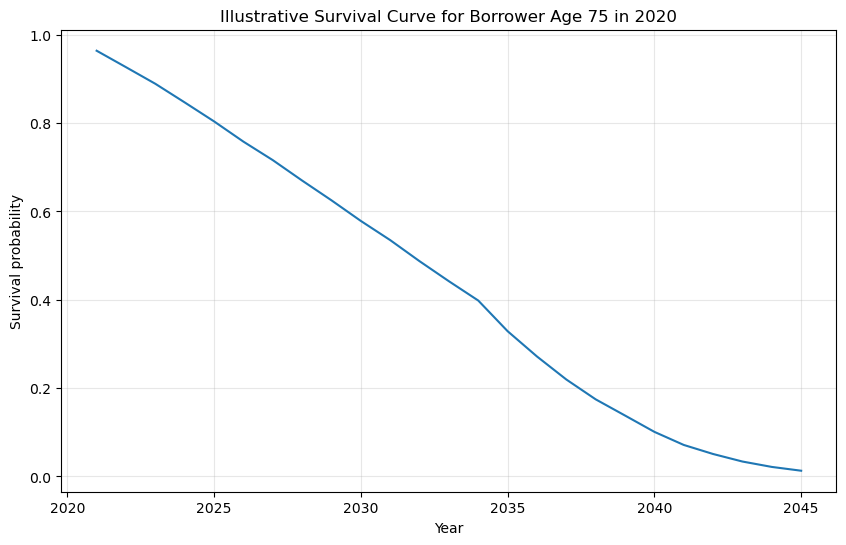

In [12]:
# App interpretation
#
# Mortality affects r m valuation because lower projected mortality
# means borrowers are expected to remain in the property longer.
#
# Longer survival usually means:
# - later loan repayment
# - higher accumulated loan balance
# - greater house-price and collateral risk
#
# A simplified survival calculation can be based on projected qx.
# If a borrower is age 75 in 2020, then in 2021 they are age 76, in 2022 age 77, etc.

def survival_curve_from_projected_qx(start_age, start_year, projected_table):
    survival = 1.0
    rows = []

    for year in projected_table.index:
        attained_age = start_age + (year - start_year)
        if attained_age not in projected_table.columns:
            break

        q = projected_table.loc[year, attained_age]
        survival *= (1 - q)

        rows.append({
            "Year": year,
            "Attained age": attained_age,
            "qx": q,
            "Survival probability": survival,
        })

    return pd.DataFrame(rows)

surv_75 = survival_curve_from_projected_qx(
    start_age=75,
    start_year=BASE_YEAR,
    projected_table=projected_qx,
)

display(surv_75.head())
display(surv_75.tail())

plt.figure(figsize=(10, 6))
plt.plot(surv_75["Year"], surv_75["Survival probability"])
plt.title("Illustrative Survival Curve for Borrower Age 75 in 2020")
plt.xlabel("Year")
plt.ylabel("Survival probability")
plt.grid(True, alpha=0.3)
plt.show()


# Method comparison notes

## Improvement-factor method

Formula:

q_x,t = q_x,base × product(1 - MI_x,t)

Advantages:
- Transparent
- Easy to apply to any base table
- Works well for deterministic valuation
- Can vary assumptions by cohort
- Suitable for r m projection work

Disadvantages:
- Can understate uncertainty if deterministic only
- Historical improvement may not continue
- Noisy at very old ages
- Needs smoothing and judgement

## Age-setback method

Formula:

q_projected_x = q_base_(x - setback)

Advantages:
- Very simple
- Useful for quick approximation
- Easy to communicate

Disadvantages:
- Crude
- Does not naturally vary by projection year
- Does not capture cohort-specific improvement trends
- Less suitable for long-horizon r m valuation

## Monte Carlo method

Formula:

simulate MI_x,t, then apply q_x,t = q_x,t-1 × (1 - MI_x,t)

Advantages:
- Captures uncertainty
- Produces distributions and tail outcomes
- Useful for capital, stress testing, and risk appetite

Disadvantages:
- More complex
- Requires assumptions about volatility and correlations
- Results can be misleading if the stochastic model is poorly calibrated

## Projection vs prediction

For projection:
- Improvement-factor method is usually better because it is clear and conditional on assumptions.
- Monte Carlo is best when you need projection uncertainty.

For prediction:
- A validated stochastic model is better because prediction requires probabilistic accuracy and back-testing.
- Age-setback is usually too crude for prediction.


In [13]:
# Optional exports

qx.to_csv("dummy_mortality_rates_qx_1950_2020.csv")
mi.to_csv("dummy_mortality_improvement_factors_1951_2020.csv")
projected_qx.to_csv("projected_mortality_rates_qx_2021_2050.csv")
mc_summary_2050.to_csv("monte_carlo_projection_summary_2050.csv")

print("Exported:")
print("- dummy_mortality_rates_qx_1950_2020.csv")
print("- dummy_mortality_improvement_factors_1951_2020.csv")
print("- projected_mortality_rates_qx_2021_2050.csv")
print("- monte_carlo_projection_summary_2050.csv")


Exported:
- dummy_mortality_rates_qx_1950_2020.csv
- dummy_mortality_improvement_factors_1951_2020.csv
- projected_mortality_rates_qx_2021_2050.csv
- monte_carlo_projection_summary_2050.csv
